# Assignment 1 — Predicting Hospital Readmission of Diabetic Patients



## 1. Imports and data loading

We start by importing every library used in the notebook in a single place, so the
notebook can be run top-to-bottom on a fresh kernel. We then load the raw dataset.

In [1]:
# --- Standard data-handling libraries ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- scikit-learn: pre-processing ---
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- scikit-learn: model selection ---
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     cross_val_predict, GridSearchCV)

# --- scikit-learn: models ---
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# --- scikit-learn: metrics ---
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

# Fixed random seed so every result in the notebook is reproducible.
RANDOM_STATE = 42

# Cosmetic settings for the plots.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


In [2]:
# Load the raw dataset provided with the assignment.
df = pd.read_csv('../data/diabetic_readmission.csv')

# Quick look at the first rows to confirm the file was read correctly.
df.head()

,Unnamed: 0,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,change,diabetesMed,readmitted
0,0,41186889,Caucasian,Female,[80-90),1,6,7,13,69,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
1,1,83591073,Caucasian,Female,[80-90),6,1,17,5,34,...,No,No,Steady,No,No,No,No,No,No,NO
2,2,68337009,Other,Male,[60-70),1,2,1,1,37,...,No,No,Steady,Steady,No,No,No,No,Yes,NO
3,3,73175076,Caucasian,Male,[40-50),1,1,7,4,56,...,No,No,Steady,Up,No,No,No,Ch,Yes,YES
4,4,31718349,Caucasian,Female,[70-80),1,1,7,1,38,...,No,No,Steady,No,No,No,No,No,No,NO


## 2. Initial exploration

Before touching anything we inspect the structure of the data: how many rows and columns
there are, the data type of each column, and basic summary statistics. This tells us which
columns are numeric, which are categorical, and where the obvious problems are.

In [3]:
# Shape of the dataset: (number of patients, number of columns).
print("Dataset shape:", df.shape)

# Data type and non-null count of every column.
df.info()

Dataset shape: (5000, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                5000 non-null   int64  
 1   patient_nbr               5000 non-null   int64  
 2   race                      5000 non-null   object 
 3   gender                    5000 non-null   object 
 4   age                       5000 non-null   object 
 5   admission_type_id         5000 non-null   int64  
 6   discharge_disposition_id  5000 non-null   int64  
 7   admission_source_id       5000 non-null   int64  
 8   time_in_hospital          5000 non-null   int64  
 9   num_lab_procedures        5000 non-null   int64  
 10  num_procedures            5000 non-null   int64  
 11  num_medications           5000 non-null   int64  
 12  number_outpatient         5000 non-null   int64  
 13  number_emergency          5000 non-nu

In [4]:
# Statistical summary of every column.
df.describe(include='all')

,Unnamed: 0,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,change,diabetesMed,readmitted
count,5000.000000,5.000000e+03,5000,5000,5000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,NaN,NaN,6,2,10,NaN,NaN,NaN,NaN,NaN,...,2,1,2,4,4,2,1,2,2,2
top,NaN,NaN,Caucasian,Female,[70-80),NaN,NaN,NaN,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Yes,NO
freq,NaN,NaN,3759,2701,1241,NaN,NaN,NaN,NaN,NaN,...,4999,5000,3457,2329,4967,4999,5000,2692,3860,2718
mean,2499.500000,5.422552e+07,NaN,NaN,NaN,2.03220,3.700400,5.704000,4.430400,43.195200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1443.520003,3.849572e+07,NaN,NaN,NaN,1.45643,5.265148,3.951393,3.009612,19.761316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,5.220000e+03,NaN,NaN,NaN,1.00000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1249.750000,2.340186e+07,NaN,NaN,NaN,1.00000,1.000000,1.000000,2.000000,31.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2499.500000,4.534128e+07,NaN,NaN,NaN,1.00000,1.000000,7.000000,4.000000,44.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3749.250000,8.722371e+07,NaN,NaN,NaN,3.00000,3.250000,7.000000,6.000000,57.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A first observation: the age column is stored as an object (text) because it contains
ranges such as [70-80) rather than exact numbers. It is therefore an ordinal
categorical variable, not a numeric one.

### Target variable

The column to predict is readmitted. We check how balanced the two classes are, because
a strong imbalance would change which metrics and techniques are appropriate.

In [5]:
# Count of each class in the target column.
target_counts = df['readmitted'].value_counts()
print(target_counts)
print("\nClass proportions:")
print(df['readmitted'].value_counts(normalize=True).round(3))

readmitted
NO     2718
YES    2282
Name: count, dtype: int64

Class proportions:
readmitted
NO     0.544
YES    0.456
Name: proportion, dtype: float64


The classes are balanced. This means plain accuracy
is a meaningful metric, and we do not need aggressive resampling techniques — although we
will still look at F1-score and ROC-AUC to get a fuller picture.

## 3. Missing values and placeholders

This dataset uses the string '?' as a
placeholder. We inspect every categorical column to find these placeholders.

In [6]:
# Print the unique values of every categorical (object) column.
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

race: ['Caucasian' 'Other' 'Hispanic' 'AfricanAmerican' '?' 'Asian']
gender: ['Female' 'Male']
age: ['[80-90)' '[60-70)' '[40-50)' '[70-80)' '[50-60)' '[30-40)' '[20-30)'
 '[90-100)' '[10-20)' '[0-10)']
chlorpropamide: ['No' 'Up' 'Steady']
glimepiride: ['No' 'Steady' 'Up' 'Down']
acetohexamide: ['No']
glyburide: ['No' 'Steady' 'Up' 'Down']
tolbutamide: ['?' 'No']
pioglitazone: ['No' 'Steady' 'Up' 'Down']
rosiglitazone: ['No' 'Steady' 'Up' 'Down']
troglitazone: ['No']
tolazamide: ['No' 'Steady']
examide: ['No']
citoglipton: ['Steady' 'No']
insulin: ['Steady' 'No' 'Up' 'Down']
glyburide-metformin: ['No' 'Down' 'Up' 'Steady']
glipizide-metformin: ['No' 'Steady']
metformin-rosiglitazone: ['No']
change: ['No' 'Ch']
diabetesMed: ['Yes' 'No']
readmitted: ['NO' 'YES']


In [7]:
# Identify exactly which columns contain the '?' placeholder.
cols_with_placeholder = [c for c in df.select_dtypes(include='object').columns
                         if '?' in df[c].values]
print("Columns containing '?':", cols_with_placeholder)

# Count how many '?' values each of those columns has.
for col in cols_with_placeholder:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Columns containing '?': ['race', 'tolbutamide']

race:
race
Caucasian          3759
AfricanAmerican     923
?                   112
Hispanic             95
Other                72
Asian                39
Name: count, dtype: int64

tolbutamide:
tolbutamide
?     3993
No    1007
Name: count, dtype: int64


Two columns contain placeholders:

* race: 112 '?' values. Since this is a small fraction and the
  column already has an Other category, we will replace '?' with Other. This keeps
  all 5000 patients instead of throwing rows away.
* tolbutamide: 3993 '?' values out of 5000. Only '?' and 'No' appear, so once
  the placeholder is resolved the column is essentially constant and carries no predictive
  information. We will drop the whole column.

## 4. Data cleaning

The cleaning steps are:

1. Drop identifier columns Unnamed: 0 (a row index) and patient_nbr (a patient ID).
2. Constant / near-constant medication columns:drop several drug columns contain a single value (or all-but-one).
3. Tolbutamide: essentially constant after the placeholder analysis → dropped.
4. Race: replace '?' 'with Other'.
5. diag_4 analysed below, then dropped.
6. diag_1, diag_2, diag_3: ICD-9 codes grouped into broad medical categories.

In [12]:
# Work on a copy so the original raw dataframe is preserved.
data = df.copy()

# --- Step 1: drop identifier columns ---
data = data.drop(columns=['Unnamed: 0', 'patient_nbr'])

# --- Step 2 & 3: drop constant / near-constant categorical columns ---
# These were identified in Section 3: they contain a single value (or all-but-one),
# and 'tolbutamide' is effectively constant once the '?' placeholder is accounted for.
constant_cols = ['chlorpropamide', 'acetohexamide', 'troglitazone', 'tolazamide',
                 'examide', 'glipizide-metformin', 'metformin-rosiglitazone',
                 'tolbutamide']
data = data.drop(columns=constant_cols)

# --- Step 4: handle the '?' placeholder in 'race' ---
data['race'] = data['race'].replace('?', 'Other')

print("Shape after dropping identifier/constant columns:", data.shape)
print("\nRace value counts after cleaning:")
print(data['race'].value_counts())

Shape after dropping identifier/constant columns: (5000, 28)

Race value counts after cleaning:
race
Caucasian          3759
AfricanAmerican     923
Other               184
Hispanic             95
Asian                39
Name: count, dtype: int64


### 4.1 Analysis of the diag_4 column

The original dataset described in the reference paper only has three diagnosis columns
(diag_1, diag_2, diag_3). This subset contains an extra diag_4 column, and its
values are floats with decimals — unlike the real ICD-9 codes in the other diagnosis
columns, which are integers. Before dropping it we verify whether it carries any signal.

In [13]:
# Convert the diagnosis columns to numeric so we can correlate them.
for d in ['diag_1', 'diag_2', 'diag_3', 'diag_4']:
    data[f'{d}_num'] = pd.to_numeric(data[d], errors='coerce')

# Numeric version of the target for the correlation check.
readmit_num = (data['readmitted'] == 'YES').astype(int)

# Correlation of diag_4 with the other diagnosis columns and with the target.
print("Correlation diag_4 vs diag_1:", data['diag_4_num'].corr(data['diag_1_num']).round(3))
print("Correlation diag_4 vs diag_2:", data['diag_4_num'].corr(data['diag_2_num']).round(3))
print("Correlation diag_4 vs diag_3:", data['diag_4_num'].corr(data['diag_3_num']).round(3))
print("Correlation diag_4 vs readmitted:", data['diag_4_num'].corr(readmit_num).round(3))

Correlation diag_4 vs diag_1: 0.009
Correlation diag_4 vs diag_2: 0.895
Correlation diag_4 vs diag_3: 0.084
Correlation diag_4 vs readmitted: 0.014


`diag_4` is **almost perfectly correlated with `diag_2`** (~0.89) but has **essentially zero
correlation with the target** (~0.01). It is redundant with `diag_2` and adds no predictive
value, so we drop it (together with the temporary numeric helper columns).

In [14]:
# Drop diag_4 (redundant, no signal) and the temporary numeric helper columns.
data = data.drop(columns=['diag_4'] + [f'{d}_num' for d in ['diag_1', 'diag_2', 'diag_3', 'diag_4']])
print("Shape after dropping diag_4:", data.shape)

Shape after dropping diag_4: (5000, 27)


### 5.2 Grouping ICD-9 diagnosis codes

`diag_1`, `diag_2` and `diag_3` contain ICD-9 codes. There are hundreds of distinct codes,
which would explode into hundreds of one-hot columns and overfit easily. Instead we map each
code to the broad **ICD-9 chapter** it belongs to (Circulatory, Respiratory, Endocrine, …),
following the standard ICD-9 ranges.

In [15]:
def map_icd9(code):
    # Map a single ICD-9 code to its broad medical category (ICD-9 chapter).
    # Missing / non-coded values.
    if pd.isna(code) or code in ['?', 'nan', '']:
        return 'Unknown'
    # Some codes (E/V codes) are not plain numbers -> group them as 'Other'.
    try:
        code_num = int(float(code))
    except ValueError:
        return 'Other'
    # Standard ICD-9 chapter ranges.
    if code_num < 140:   return 'Infectious'
    elif code_num < 240: return 'Neoplasms'
    elif code_num < 280: return 'Endocrine/Metabolic'
    elif code_num < 290: return 'Blood'
    elif code_num < 320: return 'Mental'
    elif code_num < 390: return 'Nervous'
    elif code_num < 460: return 'Circulatory'
    elif code_num < 520: return 'Respiratory'
    elif code_num < 580: return 'Digestive'
    elif code_num < 630: return 'Genitourinary'
    elif code_num < 680: return 'Pregnancy'
    elif code_num < 710: return 'Skin'
    elif code_num < 740: return 'Musculoskeletal'
    elif code_num < 760: return 'Congenital'
    elif code_num < 780: return 'Perinatal'
    elif code_num < 800: return 'Symptoms'
    elif code_num < 1000: return 'Injury/Poisoning'
    else:                return 'Other'

# Create one grouped category column per diagnosis column.
for d in ['diag_1', 'diag_2', 'diag_3']:
    data[f'{d}_cat'] = data[d].astype(str).apply(map_icd9)

# Drop the original high-cardinality ICD-9 code columns.
data = data.drop(columns=['diag_1', 'diag_2', 'diag_3'])

# Check the resulting category distribution.
print(data['diag_1_cat'].value_counts())


diag_1_cat
Circulatory            1521
Endocrine/Metabolic     577
Respiratory             506
Digestive               451
Symptoms                356
Injury/Poisoning        325
Genitourinary           251
Musculoskeletal         225
Infectious              222
Neoplasms               163
Skin                    140
Mental                  106
Nervous                  61
Blood                    50
Pregnancy                45
Congenital                1
Name: count, dtype: int64


## 6. Pre-processing pipeline

We now separate the features (X) from the target (y) and classify each feature
so it can be encoded correctly:

* Numeric features → standardised (StandardScaler).
* Ordinal feature (age) → encoded with OrdinalEncoder using the natural order of the
  age ranges, so the model sees [0-10) < [10-20) < ....
* Nominal features → one-hot encoded (OneHotEncoder).

All of this is wrapped in a ColumnTransformer so the exact same transformation is applied
consistently inside every model pipeline and during cross-validation.

In [16]:
# Separate features and target.
X = data.drop(columns='readmitted')
y = (data['readmitted'] == 'YES').astype(int)   # 1 = readmitted, 0 = not readmitted

# --- Classify the columns by the type of encoding they need ---
numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_emergency',
                    'number_inpatient', 'number_diagnoses']

ordinal_features = ['age']

nominal_features = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id',
                    'admission_source_id', 'glimepiride', 'glyburide', 'pioglitazone',
                    'rosiglitazone', 'citoglipton', 'insulin', 'glyburide-metformin',
                    'change', 'diabetesMed', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

# Explicit, ordered list of the age categories (used by the OrdinalEncoder).
age_categories = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                  '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

print("X shape:", X.shape)
print("Columns:", X.columns.tolist())

X shape: (5000, 26)
Columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'glimepiride', 'glyburide', 'pioglitazone', 'rosiglitazone', 'citoglipton', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']


In [17]:
# Define the transformer for each group of columns.
numeric_transformer = StandardScaler()
ordinal_transformer = OrdinalEncoder(categories=[age_categories])
nominal_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine them into a single ColumnTransformer.
# Each transformer is applied only to its assigned columns.
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features),
])

### 7. Results

### 7.1. Train/data split
We hold out 20% of the data as a **test set** that no model sees during training or tuning.
The split is **stratified** on the target so both sets keep the same class proportions.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,          # keep the same NO/YES ratio in both sets
)
print("Train set:", X_train.shape, " Test set:", X_test.shape)

Train set: (4000, 26)  Test set: (1000, 26)


### 7.2. Baseline model

Before training real models we establish a baseline with DummyClassifier, which
ignores the features and always predicts the majority class. Any useful model must clearly
beat this baseline.

In [19]:
# Baseline: always predict the most frequent class.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline (DummyClassifier) ===")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

=== Baseline (DummyClassifier) ===
              precision    recall  f1-score   support

           0       0.54      1.00      0.70       544
           1       0.00      0.00      0.00       456

    accuracy                           0.54      1000
   macro avg       0.27      0.50      0.35      1000
weighted avg       0.30      0.54      0.38      1000



### 7.3. Model comparison

We compare seven classifiers, each wrapped in a Pipeline with the pre-processor so that
encoding happens inside cross-validation (avoiding data leakage):

* Logistic Regression: a simple, interpretable linear baseline model.
* K-Nearest Neighbours (KNN): a distance-based, non-parametric classifier.
* Gaussian Naive Bayes: a probabilistic classifier assuming feature independence.
* Decision Tree: a single interpretable tree, easy to visualise and explain.
* Support Vector Machine (SVM, RBF kernel): margin-based classifier with kernel trick for non-linear boundaries.
* Random Forest: an ensemble of decision trees, captures non-linear interactions.
* Gradient Boosting: a boosted tree ensemble, often the strongest on tabular data.


In [20]:
# Build one pipeline per model: pre-processing + classifier.
# SVC needs probability=True so we can compute ROC-AUC from predict_proba.
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=15)),
    ]),
    'Naive Bayes': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB()),
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    'SVM (RBF)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}


### 7.4. Cross-validation

We evaluate each pipeline with 5-fold stratified cross-validation on the training set,
reporting three metrics: accuracy, F1-score and ROC-AUC. Cross-validation gives a more
reliable estimate than a single split and shows the variance across folds.

In [21]:
# Metrics computed for every fold.
scoring = ['accuracy', 'f1', 'roc_auc']

cv_results = []
for name, pipe in pipelines.items():
    # cross_validate returns one array of scores per metric.
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'F1': scores['test_f1'].mean(),
        'F1_std': scores['test_f1'].std(),
        'ROC_AUC': scores['test_roc_auc'].mean(),
        'ROC_AUC_std': scores['test_roc_auc'].std(),
    })

# Show the results as a tidy table, sorted by ROC-AUC.
cv_table = pd.DataFrame(cv_results).set_index('Model').round(3)
cv_table.sort_values('ROC_AUC', ascending=False)

,Accuracy,Accuracy_std,F1,F1_std,ROC_AUC,ROC_AUC_std
Model,,,,,,
SVM (RBF),0.632,0.009,0.484,0.010,0.677,0.015
Gradient Boosting,0.633,0.008,0.539,0.013,0.674,0.010
Logistic Regression,0.630,0.018,0.539,0.021,0.672,0.011
Random Forest,0.624,0.017,0.544,0.016,0.665,0.015
KNN,0.573,0.012,0.481,0.023,0.599,0.010
Naive Bayes,0.493,0.006,0.636,0.004,0.557,0.009
Decision Tree,0.551,0.021,0.511,0.019,0.548,0.020


### 7.5. ROC curves of all models

To compare the models visually we overlay the ROC curve of each classifier on a single
plot. The predicted probabilities are obtained with `cross_val_predict` (out-of-fold
predictions across the 5 folds), so the held-out test set is still never used here. A
curve closer to the top-left corner — and a larger area under it (AUC) — indicates a
better classifier; the dashed diagonal is a random classifier (AUC = 0.5).

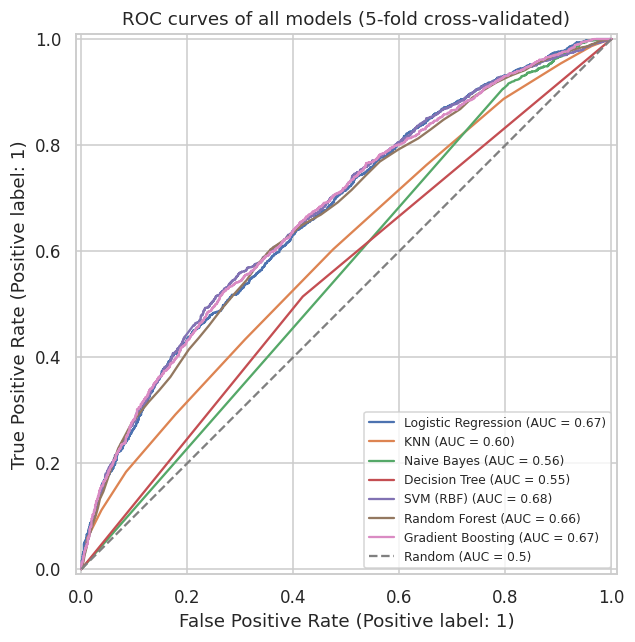

In [22]:
# For each model, obtain out-of-fold predicted probabilities with 5-fold
# cross_val_predict (this keeps the held-out test set untouched) and overlay
# every ROC curve on a single plot for a direct visual comparison.
fig, ax = plt.subplots(figsize=(7, 6))

for name, pipe in pipelines.items():
    # Out-of-fold probability of the positive class (YES).
    y_proba_cv = cross_val_predict(pipe, X_train, y_train, cv=5,
                                   method='predict_proba')[:, 1]
    RocCurveDisplay.from_predictions(y_train, y_proba_cv, name=name, ax=ax)

# Diagonal reference line = a random classifier (AUC = 0.5).
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random (AUC = 0.5)')
ax.set_title("ROC curves of all models (5-fold cross-validated)")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### 7.6. Hyper-parameter tuning

We tune the two tree-based models with GridSearchCV (5-fold CV, optimising ROC-AUC). The
parameter names are prefixed with classifier because the estimator lives inside a
Pipeline.

In [23]:
# --- Grid search for Random Forest ---
rf_param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [1, 5],
}
rf_search = GridSearchCV(pipelines['Random Forest'], rf_param_grid,
                         cv=5, scoring='roc_auc', n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Random Forest -- best params:", rf_search.best_params_)
print("Random Forest -- best CV ROC-AUC:", round(rf_search.best_score_, 3))

Random Forest -- best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Random Forest -- best CV ROC-AUC: 0.679


In [24]:
# --- Grid search for Gradient Boosting ---
gb_param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [2, 3],
}
gb_search = GridSearchCV(pipelines['Gradient Boosting'], gb_param_grid,
                         cv=5, scoring='roc_auc', n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Gradient Boosting -- best params:", gb_search.best_params_)
print("Gradient Boosting -- best CV ROC-AUC:", round(gb_search.best_score_, 3))

Gradient Boosting -- best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}
Gradient Boosting -- best CV ROC-AUC: 0.676


In [25]:
# Pick the better of the two tuned models as our final model.
if gb_search.best_score_ >= rf_search.best_score_:
    best_name, best_model = 'Gradient Boosting (tuned)', gb_search.best_estimator_
else:
    best_name, best_model = 'Random Forest (tuned)', rf_search.best_estimator_

print("Selected best model:", best_name)

Selected best model: Random Forest (tuned)


### 7.7. Final evaluation on the test set

We now evaluate the selected model once on the held-out test set — data it has never
seen. We report the classification report, the confusion matrix and the ROC curve.

In [26]:
# Predictions and predicted probabilities on the untouched test set.
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"=== Final evaluation: {best_name} ===")
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

=== Final evaluation: Random Forest (tuned) ===
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       544
           1       0.65      0.45      0.53       456

    accuracy                           0.64      1000
   macro avg       0.64      0.63      0.62      1000
weighted avg       0.64      0.64      0.63      1000

Test ROC-AUC: 0.696


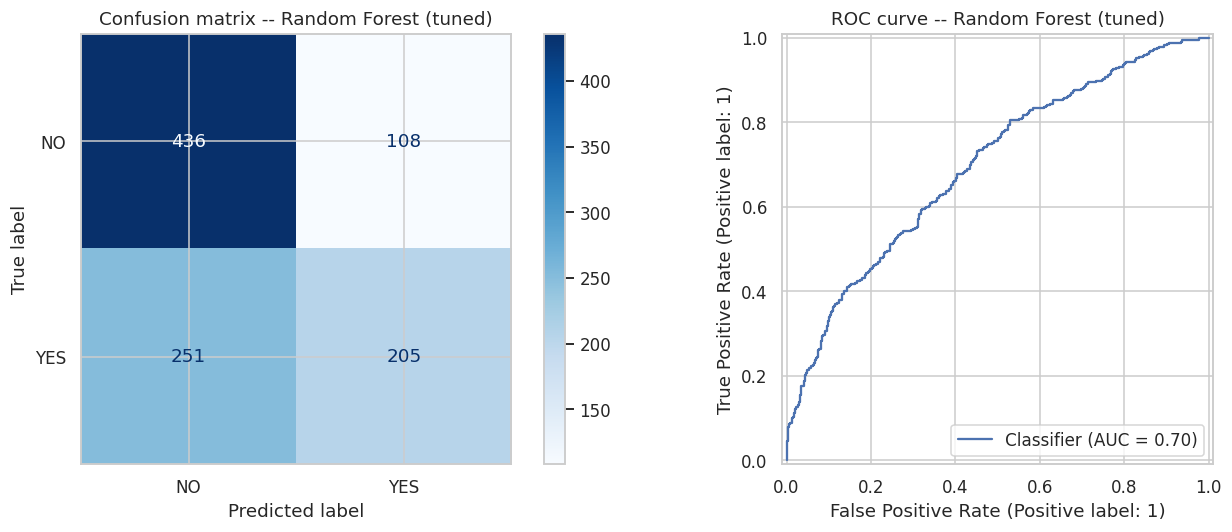

In [27]:
# Confusion matrix and ROC curve side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['NO', 'YES'], ax=axes[0], cmap='Blues')
axes[0].set_title(f"Confusion matrix -- {best_name}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC curve -- {best_name}")

plt.tight_layout()
plt.show()

### 7.8. Feature importance

Finally we inspect which features the best model relies on most. For tree-based models this
comes from the impurity-based feature_importances. We map the importances back to the
(one-hot expanded) feature names produced by the ColumnTransformer.

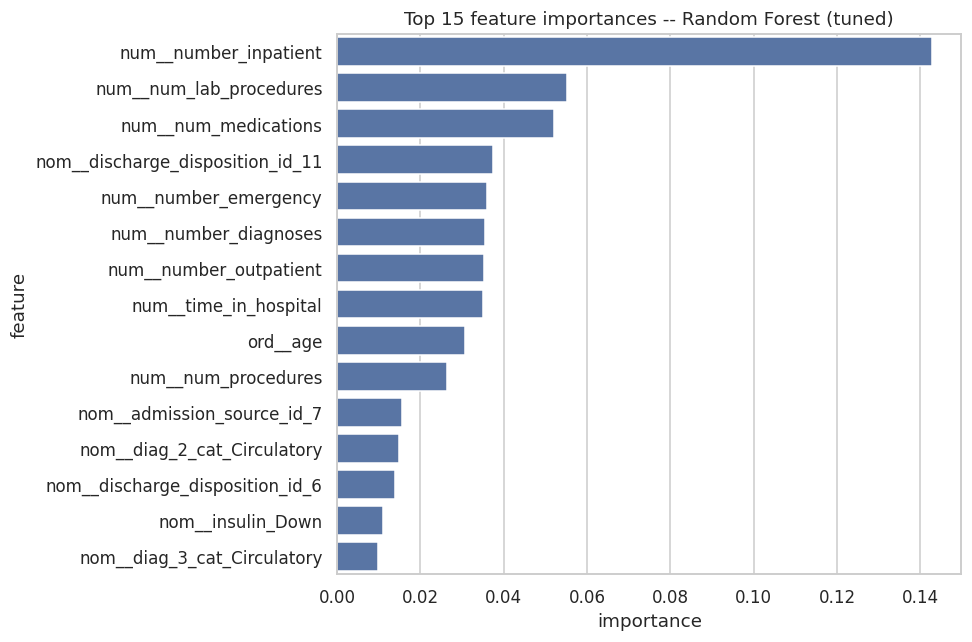

,feature,importance
0,num__number_inpatient,0.142726
1,num__num_lab_procedures,0.055120
2,num__num_medications,0.052008
3,nom__discharge_disposition_id_11,0.037484
4,num__number_emergency,0.036096
5,num__number_diagnoses,0.035514
6,num__number_outpatient,0.035210
7,num__time_in_hospital,0.034968
8,ord__age,0.030738
9,num__num_procedures,0.026467


In [28]:
# Recover the feature names after the ColumnTransformer expansion (one-hot, etc.).
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Impurity-based importances from the fitted tree ensemble.
importances = best_model.named_steps['classifier'].feature_importances_

# Sort and display the 15 most important features.
importance_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
                 .sort_values('importance', ascending=False)
                 .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set_title(f"Top 15 feature importances -- {best_name}")
plt.tight_layout()
plt.show()

importance_df.reset_index(drop=True)